### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _03_01_function_to_normalize_sgrna_lfc import *

In [ ]:
read_count = pd.read_csv("../data/sgrna_lfc_data/tkov3_data/matrix-reads-by-gRNA-RPE1-drugZ.txt", sep ='\t')
read_count[['gene', 'sgRNA']] = read_count['sgRNA'].str.split('_', n = 1, expand=True)

# rename gene and spacer columns
read_count = read_count.drop(columns=['GENE', 'gene'])
read_count = read_count.rename(columns={'sgRNA':'spacer'})

# filtered out sgRNA with less than 30 reads in T0
read_count = read_count[read_count['RPE1_T0'] > 30]

# drop LOPRIMER data
read_count = read_count[['spacer', 'RPE1_T0', 'RPE1_T3A_CTRL', 'RPE1_T3B_CTRL']]
display(read_count)

,spacer,RPE1_T0,RPE1_T3A_CTRL,RPE1_T3B_CTRL
0,ACTGGCGCCATCGAGAGCCA,164,93,44
1,CAAGAGAAAGACCACGAGCA,492,288,222
2,GCTCAGCTGGGTCCATCCTG,258,49,5
3,GTCGAGCTGATTCTGAGCGA,487,360,290
4,AGTTATGTTAGGTATACCCG,149,133,140
...,...,...,...,...
71085,GGTCTTCCCGACGATGACGC,320,160,59
71086,TATCGATTCCAATTCAGCGG,298,183,153
71087,TATTCTGATTACACCCGAGG,384,395,243
71088,TCTAGAGGATAGAATGGCGC,399,266,138


In [3]:
# import library data
library_data = pd.read_csv("../data/library_data/tkov3_guide_sequence.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

(71090, 3)

In [4]:
read_count = pd.merge(read_count, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="sgRNA")
read_count

,,,RPE1_T0,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,492,288,222
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,258,49,5
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,164,93,44
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,487,360,290
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,190,96,53
...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,180,232,206
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,617,433,373
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,585,235,202


In [5]:
# we log transformed the raw read counts (log2(counts + 1))

# separate plasmid count into a new column
# plasmid_count = read_count['RPE1_T0']
# plasmid_count

# main log transformed read count
# log_transformed_read_count = read_count.drop(columns=['RPE1_T0'])
log_transformed_read_count = np.log2(read_count + 1)
log_transformed_read_count

,,,RPE1_T0,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,8.945444,8.174926,7.800900
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,8.016808,5.643856,2.584963
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,7.366322,6.554589,5.491853
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,8.930737,8.495855,8.184875
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,7.577429,6.599913,5.754888
...,...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,7.499846,7.864186,7.693487
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,9.271463,8.761551,8.546894
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,9.194757,7.882643,7.665336


In [6]:
RPE1_T0 = log_transformed_read_count[['RPE1_T0']]

# Compute log-fold change relative to T0
sgrna_lfc = log_transformed_read_count.drop(columns=['RPE1_T0']).subtract(RPE1_T0.values, axis = 0)
sgrna_lfc

,,,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.770518,-1.144544
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-2.372952,-5.431846
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.811733,-1.874469
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,-0.434882,-0.745862
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.977516,-1.822541
...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.364340,0.193641
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,-0.509912,-0.724569
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-1.312114,-1.529421


In [7]:
# Center LFCs using non-essential guides
non_essential_mask = ~log_transformed_read_count.index.get_level_values(2).isin(['LacZ', 'luciferase', 'EGFP'])
median_non_essential = sgrna_lfc[non_essential_mask].median(axis=0)

median_non_essential

RPE1_T3A_CTRL   -0.992257
RPE1_T3B_CTRL   -1.405639
dtype: float64

In [8]:
# Subtract median of non-essential guides for each sample (normalized sgrna LFC)
sgrna_lfc_normalized = sgrna_lfc - median_non_essential
sgrna_lfc_normalized

,,,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,0.221739,0.261095
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.380695,-4.026207
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,0.180524,-0.468830
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.557375,0.659777
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,0.014741,-0.416903
...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,1.356598,1.599280
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,0.482346,0.681070
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.319856,-0.123782


In [9]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
norm_sgrna_lfc_scaled, list_common_essential = scale_essential(sgrna_lfc_normalized)
norm_sgrna_lfc_scaled

Scale factor:  1.9921696396809536


,,,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,0.111305,0.131061
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-0.693061,-2.021016
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,0.090617,-0.235337
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.279783,0.331185
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,0.007400,-0.209271
...,...,...,...,...
sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.680965,0.802783
sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,0.242121,0.341874
sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.160557,-0.062134


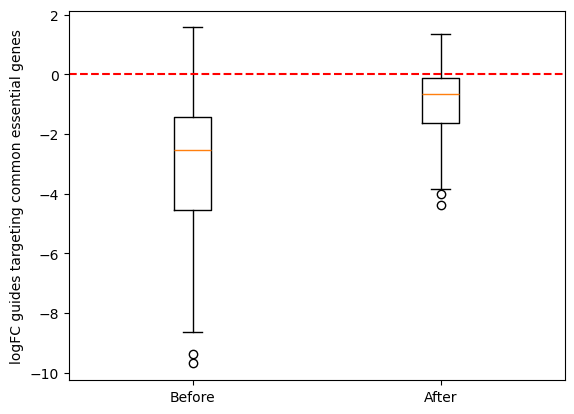

In [10]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc, norm_sgrna_lfc_scaled, list_common_essential)

In [11]:
# averaged sgRNA LFC across replicates
lfc_norm_scaled_avg = mean_row(norm_sgrna_lfc_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,0.121183
1,sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.357038
2,sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.072360
3,sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.305484
4,sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.100935
...,...,...,...,...
70056,sgluciferase_5,GCTATTCTGATTACACCCGA,luciferase,0.741874
70057,sgluciferase_6,ACGCTGGGCGTTAATCAGAG,luciferase,0.291997
70058,sgluciferase_7,GACCAACGCCTTGATTGACA,luciferase,-0.111346
70059,sgluciferase_8,CTATTCTGATTACACCCGAG,luciferase,0.325790


In [12]:
lfc_norm_scaled_avg.to_csv("../data/sgrna_lfc_data/output_normalized/tkov3_rpe1_normalized_lfc.csv", index=False)